#Model ML
*Messy working notebook, lets goooo*

In [1]:
import sys
from pathlib import Path

# Point to project root (notebook lives in notebooks/)
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
print('imports done')

imports done


## 1. Load Data

In [2]:
# Load raw data
raw_path = PROJECT_ROOT / 'data' / 'raw' / 'patient_encounters_2023.csv'
df_raw = pd.read_csv(raw_path, low_memory=False)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
# Load processed data (from your pipeline)
proc_path = PROJECT_ROOT / 'data' / 'processed' / 'patient_encounters_2023_processed.csv'
df = pd.read_csv(proc_path, low_memory=False)
print(f'Processed shape: {df.shape}')
df.head(3)

Processed shape: (94223, 66)


,encounter_id,patient_nbr,gender,age,weight_checked,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmission_binary,n_meds_changed,any_med_changed,n_meds_increased,complexity_score,num_active_meds,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,diag_1_diabetes,diag_1_digestive,diag_1_external,diag_1_other,diag_1_respiratory,diag_2_diabetes,diag_2_digestive,diag_2_external,diag_2_other,diag_2_respiratory,diag_3_diabetes,diag_3_digestive,diag_3_external,diag_3_other,diag_3_respiratory
0,149190,55629189,1,15,0,1,1,7,3,59,0,18,0,0,0,9,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,>30,1,1,1,1,3.080000,1,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False
1,64410,86047875,1,25,0,1,1,7,2,11,5,13,2,0,1,6,NaN,NaN,0,0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,NO,0,1,1,0,2.570000,1,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False
2,500364,82442376,0,35,0,1,1,7,2,44,1,16,0,0,0,7,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,NO,0,1,1,1,2.624444,1,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False


## 2. Quick EDA

In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94223 entries, 0 to 94222
Data columns (total 66 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              94223 non-null  int64  
 1   patient_nbr               94223 non-null  int64  
 2   gender                    94223 non-null  int64  
 3   age                       94223 non-null  int64  
 4   weight_checked            94223 non-null  int64  
 5   admission_type_id         94223 non-null  int64  
 6   discharge_disposition_id  94223 non-null  int64  
 7   admission_source_id       94223 non-null  int64  
 8   time_in_hospital          94223 non-null  int64  
 9   num_lab_procedures        94223 non-null  int64  
 10  num_procedures            94223 non-null  int64  
 11  num_medications           94223 non-null  int64  
 12  number_outpatient         94223 non-null  int64  
 13  number_emergency          94223 non-null  int64  
 14  number

In [5]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

max_glu_serum    89273
A1Cresult        78507
dtype: int64

readmission_binary
0    49175
1    45048
Name: count, dtype: int64

Readmission rate: 47.8%


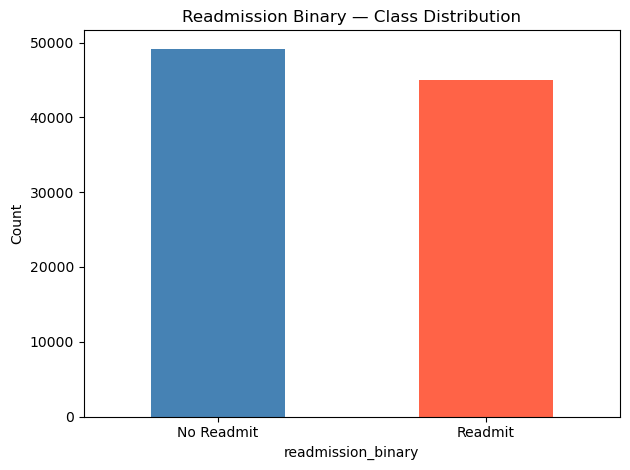

In [6]:
# Target distribution
print(df['readmission_binary'].value_counts())
print(f"\nReadmission rate: {df['readmission_binary'].mean()*100:.1f}%")

df['readmission_binary'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Readmission Binary — Class Distribution')
plt.xticks([0,1], ['No Readmit','Readmit'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

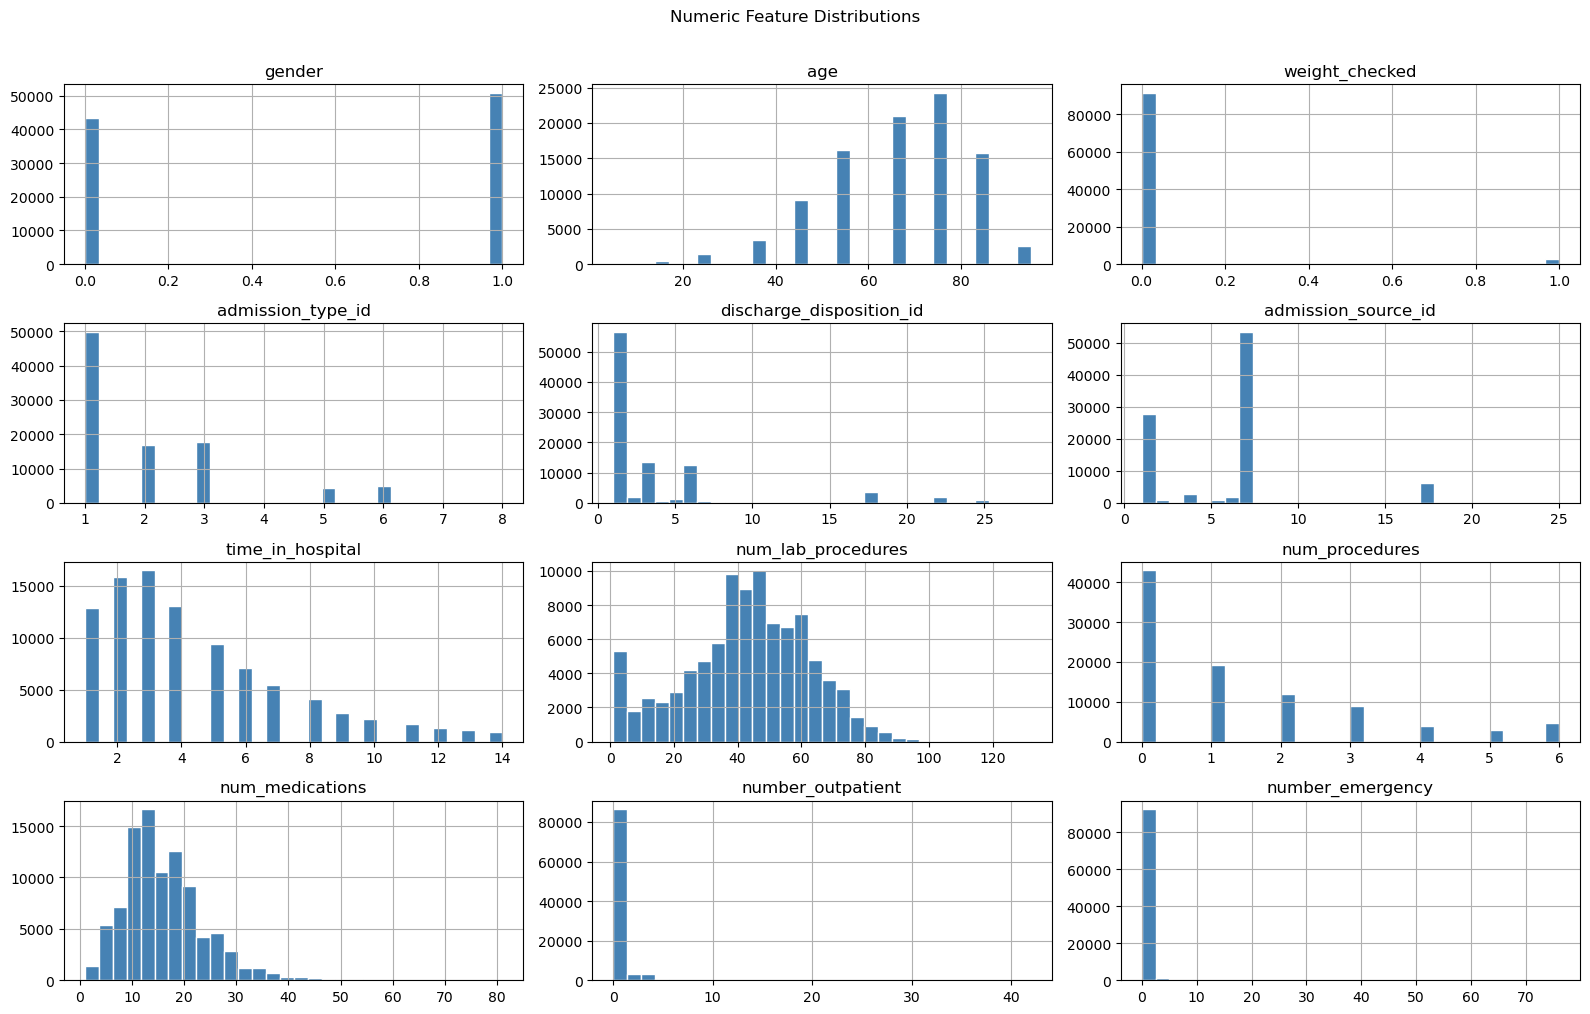

In [7]:
# Numeric feature distributions
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['readmission_binary', 'Unnamed: 0', 'encounter_id', 'patient_nbr']]

df[num_cols[:12]].hist(figsize=(16, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

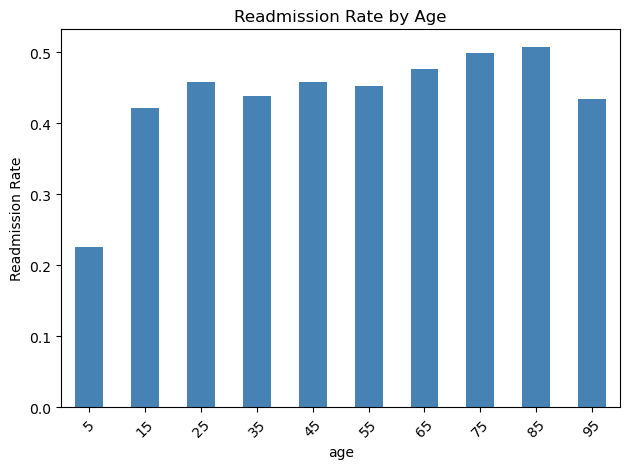

In [8]:
# Readmission rate by age
if 'age' in df.columns:
    age_readmit = df.groupby('age')['readmission_binary'].mean().sort_index()
    age_readmit.plot(kind='bar', color='steelblue')
    plt.title('Readmission Rate by Age')
    plt.ylabel('Readmission Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

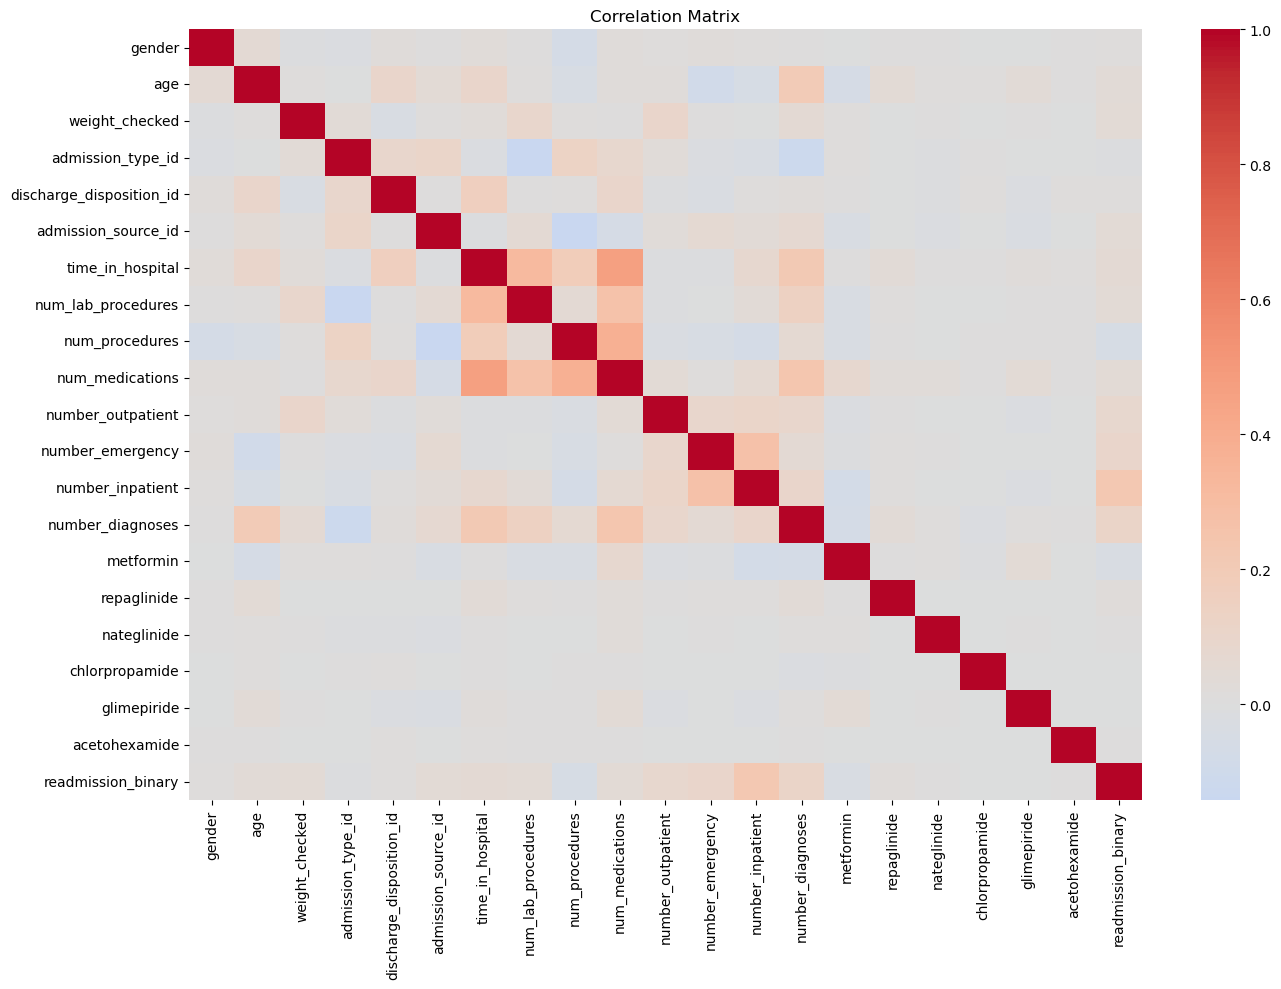

In [9]:
# Correlation heatmap (numeric only, top features by variance)
corr_cols = num_cols[:20]
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    df[corr_cols + ['readmission_binary']].corr(),
    annot=False, cmap='coolwarm', center=0, ax=ax
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

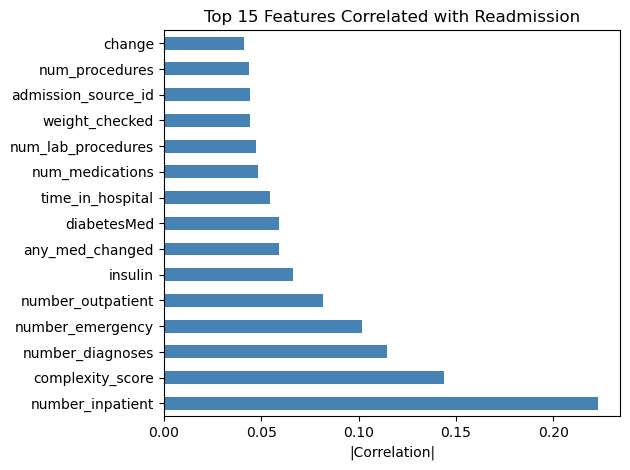

In [10]:
# Top correlations with target
corr_with_target = df[num_cols + ['readmission_binary']].corr()['readmission_binary'].drop('readmission_binary')
corr_with_target.abs().sort_values(ascending=False).head(15).plot(
    kind='barh', color='steelblue'
)
plt.title('Top 15 Features Correlated with Readmission')
plt.xlabel('|Correlation|')
plt.tight_layout()
plt.show()

## 3. Prepare Features for Modeling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

DROP_COLS = ['encounter_id', 'patient_nbr', 'Unnamed: 0', 'readmitted', 'readmission_binary']
TARGET = 'readmission_binary'

df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns and c != TARGET])

y = df[TARGET].astype(int)
X = df_model.drop(columns=[TARGET])

# One-hot encode remaining object columns
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'One-hot encoding: {obj_cols}')
    X = pd.get_dummies(X, columns=obj_cols, drop_first=True)

X = X.apply(pd.to_numeric, errors='coerce')

print(f'X shape: {X.shape}')
print(f'y distribution: {y.value_counts().to_dict()}')

One-hot encoding: ['max_glu_serum', 'A1Cresult']
X shape: (94223, 64)
y distribution: {0: 49175, 1: 45048}


In [12]:
# Train/val split — stratified because of class imbalance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}')

feature_names = X.columns.tolist()

Train: 75,378  |  Val: 18,845


## 4. Train Models

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not available')

In [14]:
# --- Logistic Regression (baseline) ---
lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr.fit(X_train, y_train)
lr_auc = roc_auc_score(y_val, lr.predict_proba(X_val)[:, 1])
print(f'Logistic Regression AUC: {lr_auc:.4f}')

Logistic Regression AUC: 0.6668


In [15]:
# --- Random Forest ---
rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
print(f'Random Forest AUC: {rf_auc:.4f}')

Random Forest AUC: 0.6793


In [16]:
# --- XGBoost (usually best) ---
if XGBOOST_AVAILABLE:
    xgb = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            n_estimators=300, max_depth=5,
            learning_rate=0.05, scale_pos_weight=3,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, n_jobs=-1
        ))
    ])
    xgb.fit(X_train, y_train)
    xgb_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
    print(f'XGBoost AUC: {xgb_auc:.4f}')

XGBoost AUC: 0.6886


                      AUC-ROC
XGBoost              0.688621
Random Forest        0.679349
Logistic Regression  0.666766

Benchmark (0.70): ❌ Not met
Stretch  (0.80): Not yet


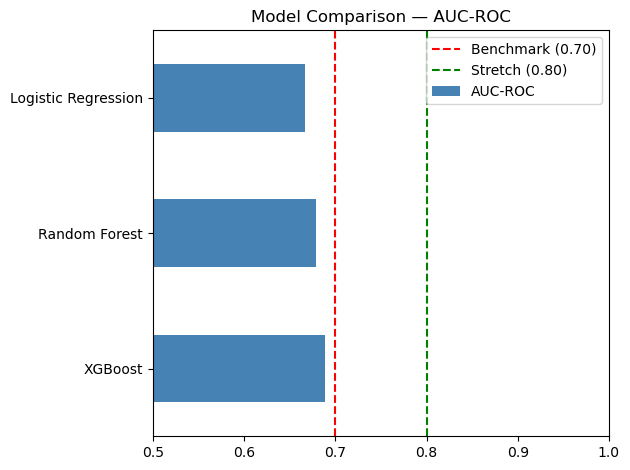

In [17]:
# --- Compare all models ---
results = {'Logistic Regression': lr_auc, 'Random Forest': rf_auc}
if XGBOOST_AVAILABLE:
    results['XGBoost'] = xgb_auc

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['AUC-ROC'])
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print(results_df)
print(f"\nBenchmark (0.70): {'✅ Met' if results_df['AUC-ROC'].max() >= 0.70 else '❌ Not met'}")
print(f"Stretch  (0.80): {'✅ Met' if results_df['AUC-ROC'].max() >= 0.80 else 'Not yet'}")

results_df['AUC-ROC'].plot(kind='barh', color='steelblue', xlim=(0.5, 1.0))
plt.axvline(x=0.70, color='red', linestyle='--', label='Benchmark (0.70)')
plt.axvline(x=0.80, color='green', linestyle='--', label='Stretch (0.80)')
plt.title('Model Comparison — AUC-ROC')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# --- Best model classification report ---
best_name = results_df.index[0]
best_model = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb if XGBOOST_AVAILABLE else rf}[best_name]

print(f'Best model: {best_name}')
print(classification_report(y_val, best_model.predict(X_val), target_names=['No Readmit', 'Readmit']))

Best model: XGBoost
              precision    recall  f1-score   support

  No Readmit       0.81      0.11      0.20      9835
     Readmit       0.50      0.97      0.66      9010

    accuracy                           0.52     18845
   macro avg       0.65      0.54      0.43     18845
weighted avg       0.66      0.52      0.42     18845



## 5. SHAP Feature Importance

In [19]:
try:
    import shap

    clf = best_model.named_steps['clf']

    # Transform through pipeline steps before clf
    X_transformed = X_train.copy()
    for step_name, step in best_model.steps[:-1]:
        X_transformed = step.transform(X_transformed)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_transformed)

    # For Random Forest, shap_values is a list — take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap.summary_plot(
        shap_values, X_transformed,
        feature_names=feature_names,
        max_display=20
    )

except ImportError:
    print('Install shap: pip install shap')
except Exception as e:
    print(f'SHAP error: {e}')

Install shap: pip install shap


In [20]:
# Bar plot version (cleaner for presentations)
try:
    shap.summary_plot(
        shap_values, X_transformed,
        feature_names=feature_names,
        max_display=20,
        plot_type='bar'
    )
except:
    pass

## 6. Notes / Next Steps
- TODO: tune hyperparameters (grid search)
- TODO: try feature selection to reduce dimensionality  
- TODO: move best model to train.py once happy with results
- TODO: compare against DNN (Model 2)